In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
import textdescriptives as td
import re
import nltk

from collections import Counter
from datasets import load_dataset
from nltk.corpus import stopwords
from tqdm import trange
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import word_tokenize

In [56]:
ds_50pct = load_dataset("takala/financial_phrasebank", "sentences_50agree")
ds_75pct = load_dataset("takala/financial_phrasebank", "sentences_75agree")
ds_100pct = load_dataset("takala/financial_phrasebank", "sentences_allagree")


print(ds_75pct)
print(ds_100pct)

/Users/adisontan/LLM-Label-Audit/venv/lib/python3.13/site-packages/datasets/load.py:1486: FutureWarning: The repository for takala/financial_phrasebank contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/takala/financial_phrasebank
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3453
    })
})
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})


In [46]:
# 0 is Negative, 1 is Neutral, 1 is Positive

df_50pct = pd.DataFrame(ds_50pct["train"])
df_75pct = pd.DataFrame(ds_75pct["train"])
df_100pct = pd.DataFrame(ds_100pct["train"])

print(df_50pct)
print(df_75pct)
print(df_100pct)

                                                                                                                                                                                                                                  sentence  \
0                                                                                                          According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   
1                                           Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .   
2     The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .   
3                           With the new product

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print(df_100pct.iloc[0])
print(df_100pct.iloc[1])
print(df_100pct.iloc[2263])

sentence    According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
label                                                                                                                                     1
Name: 0, dtype: object
sentence    For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .
label                                                                                                                                                                                                       2
Name: 1, dtype: object
sentence    Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .
label                                                                                                     0
Name: 2263, dtype: object


In [17]:
ds_train = load_dataset("Ankonbh/Financial-News-Headlines-Reuters", "default")

print(ds_train)

Generating test split: 100%|████| 8193/8193 [00:00<00:00, 326855.31 examples/s]

DatasetDict({
    train: Dataset({
        features: ['Headlines', 'Description', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 19661
    })
    val: Dataset({
        features: ['Headlines', 'Description', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 4916
    })
    test: Dataset({
        features: ['Headlines', 'Description', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 8193
    })
})


In [21]:
df_train = pd.DataFrame(ds_train["train"])
df_headlines = pd.DataFrame(df_train['Headlines'])
df_desc = pd.DataFrame(df_train['Description'])

print(df_headlines)
print(df_desc)

                                                                           Headlines
0                      French carmaker PSA launches Citroen C5 Aircross SUV in India
1                        Santander in 350 million pound deal for stake in UK's Ebury
2      Virus fears rise: Investors worry about supply chain and pandemic-type spread
3             Touchless: How the world's busiest airport envisions post-COVID travel
4                       U.S. says to expand program sending asylum seekers to Mexico
...                                                                              ...
19656      J&J recalls 33,000 bottles of baby powder as FDA finds asbestos in sample
19657         Central banks hint at pandemic stimulus exit. Markets aren't buying it
19658         Australian farmer brings legal action vs Bayer over weedkiller: report
19659                  Autonomy boss Lynch ramped sales ahead of HP deal, court told
19660          UTC gets Chinese nod for Rockwell Collins purchase

In [39]:
ds_train_2 = load_dataset("danidanou/Reuters_Financial_News", "default")

print(ds_train_2)

Generating train split: 100%|█| 105359/105359 [00:02<00:00, 44898.31 examples/s


DatasetDict({
    train: Dataset({
        features: ['Headline', 'Journalists', 'Date', 'Link', 'Summary', 'Article', '__index_level_0__'],
        num_rows: 105359
    })
})


In [40]:
df_train_2 = pd.DataFrame(ds_train_2["train"])
df_summary = pd.DataFrame(df_train_2['Summary'])

print(df_summary)

                                                                                                                                                                                                                                                                Summary
0                                              TOKYO - Hitachi Ltd. ( 6501.T ) said on Monday it has agreed with General Electric Co. ( GE.N ) to expand their global alliance in the nuclear power business, aiming to strengthen their position in a growing market. 
1                                                                                                 STOCKHOLM - Truck maker Volvo said on Monday it would cut about 1,000 staff at its Dublin, Virginia plant in the United States due to an expected decline in output. 
2        ZURICH, Nov 13 (Reuter) - West European banks are failing to disclose unfunded staff pension obligations running to billions of dollars, in contrast to U.S. banks which are required to show the full 

In [42]:
ds_fiqa = load_dataset("pauri32/fiqa-2018", "default")

print(ds_fiqa)

Generating test split: 100%|███████| 150/150 [00:00<00:00, 22928.88 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 961
    })
    validation: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 102
    })
    test: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 150
    })
})


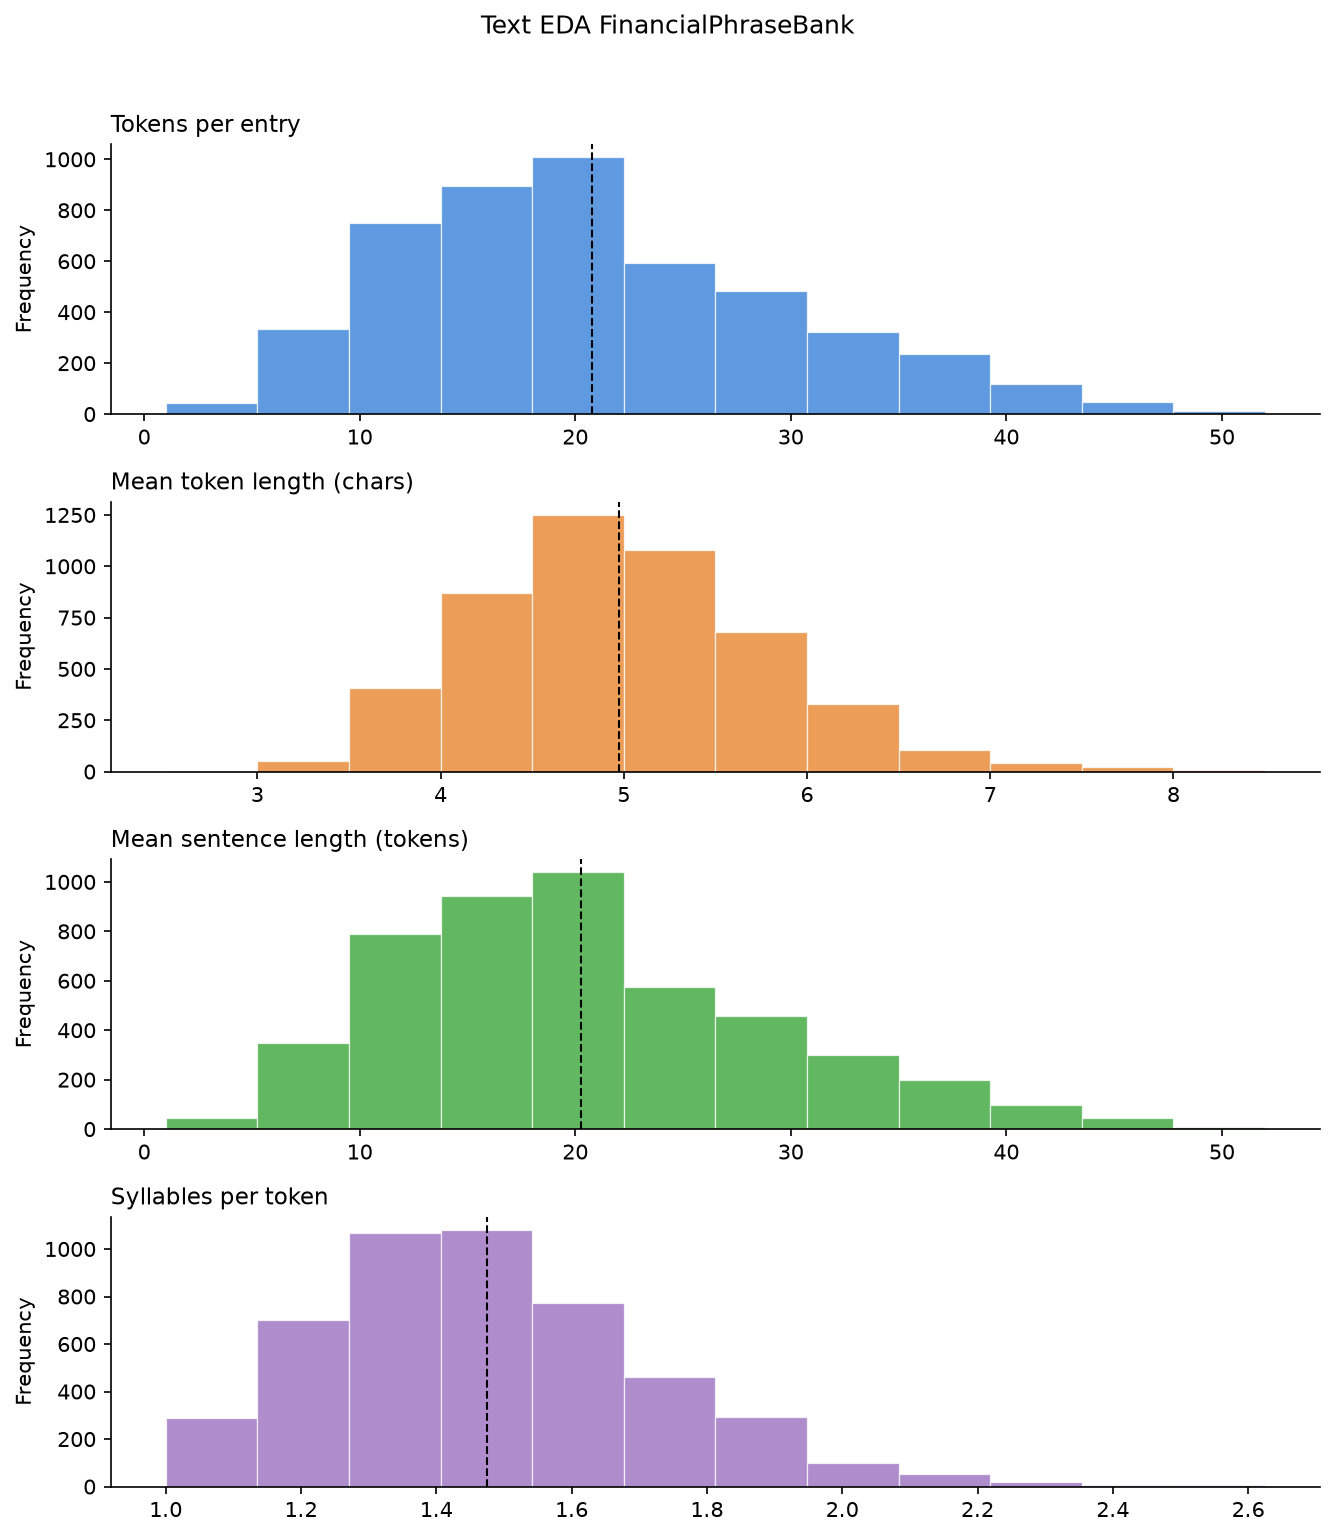

In [47]:
# text characteristics for gold dataset

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("textdescriptives/descriptive_stats")

docs = list(nlp.pipe(df_50pct["sentence"]))

text_metrics = td.extract_df(
    docs,
    metrics=["descriptive_stats"]
)

METRICS = [
    "n_tokens",
    "token_length_mean",
    "sentence_length_mean",
    "syllables_per_token_mean"
]

TITLES = {
    "n_tokens": "Tokens per entry",
    "token_length_mean": "Mean token length (chars)",
    "sentence_length_mean": "Mean sentence length (tokens)",
    "syllables_per_token_mean": "Syllables per token"
}

COLORS = ["#2a78d6", "#e67e22", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(4, 1, figsize=(9, 10), dpi=150)

fig.suptitle(
    "Text EDA FinancialPhraseBank",
    y=1.02
)

for ax, m, color in zip(axes, METRICS, COLORS):
    vals = text_metrics[m].dropna()

    ax.hist(
        vals,
        bins=12,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6
    )

    # Mean
    ax.axvline(
        vals.mean(),
        color="black",
        linewidth=1,
        linestyle="--"
    )

    ax.set_title(TITLES[m], fontsize=11, loc="left")
    ax.set_ylabel("Frequency")
    
    # Clean up
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

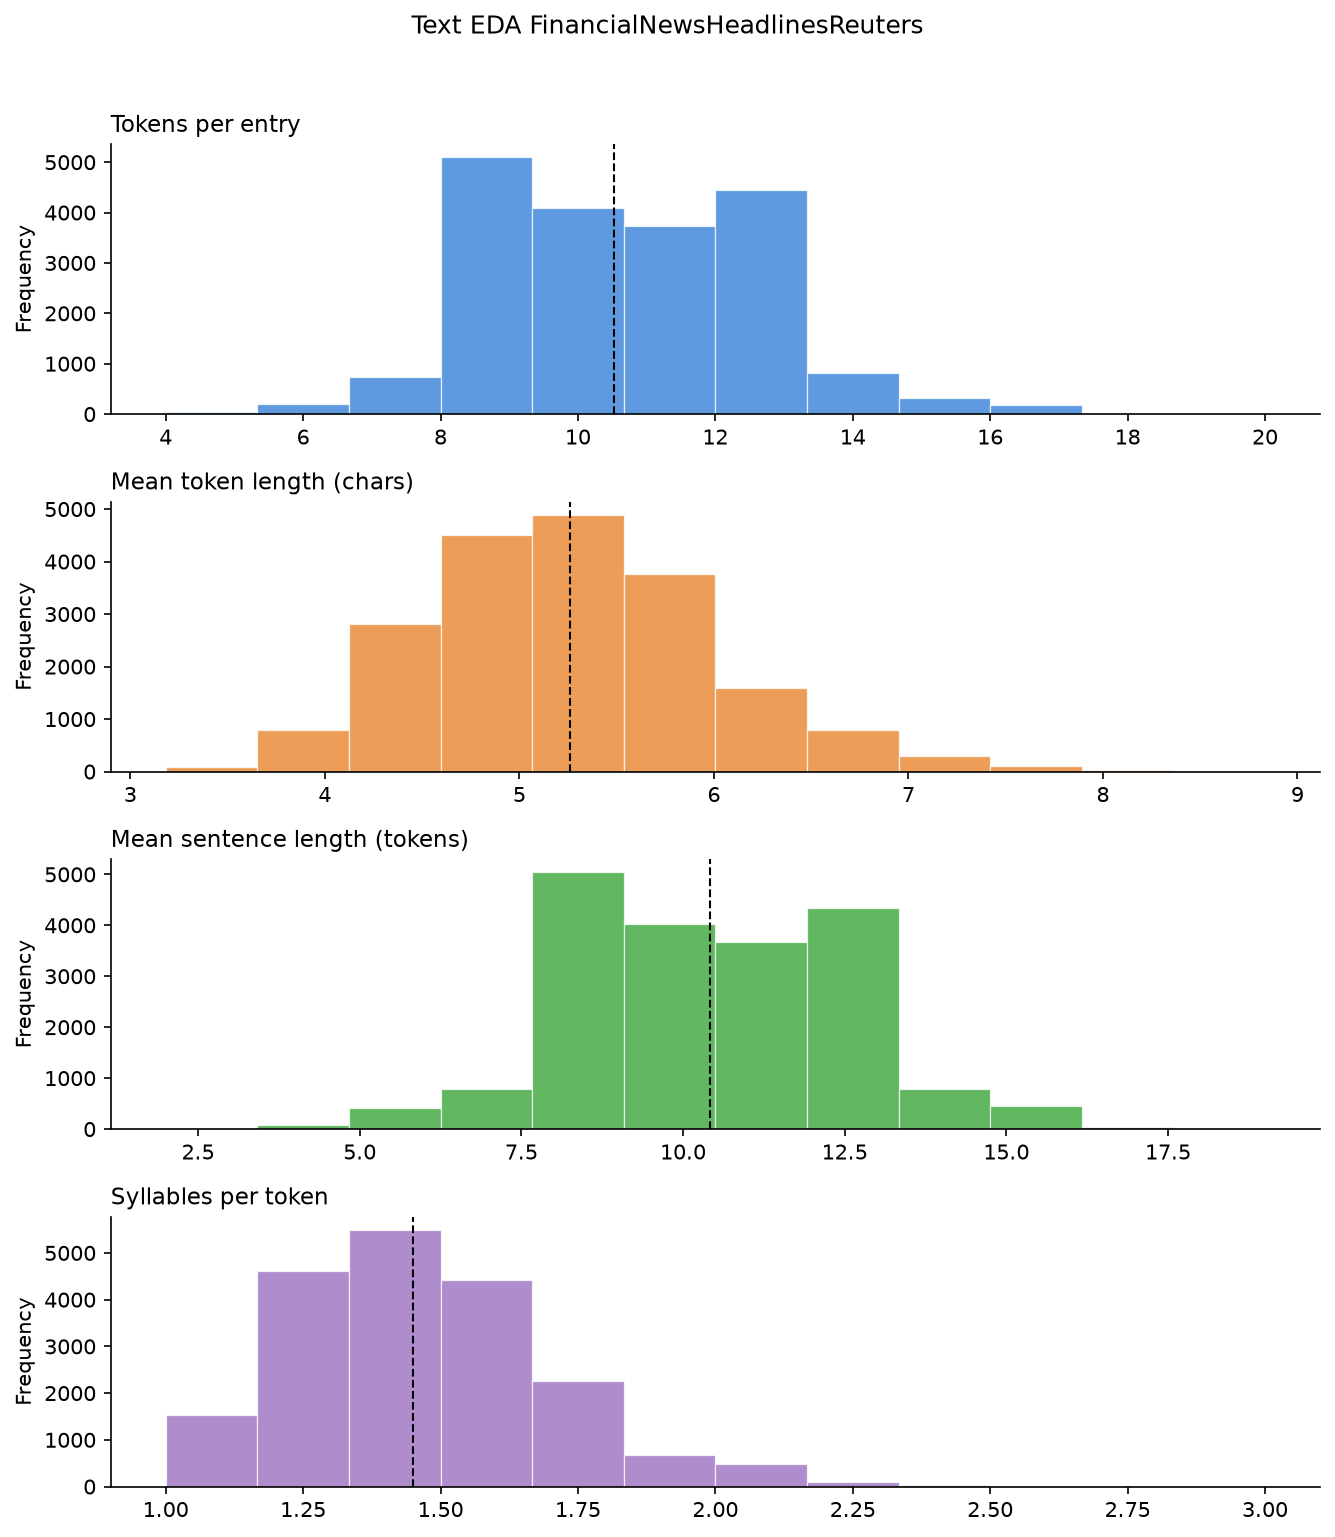

In [34]:
# text characteristics for train dataset headlines

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("textdescriptives/descriptive_stats")

docs = list(nlp.pipe(df_headlines["Headlines"]))

text_metrics = td.extract_df(
    docs,
    metrics=["descriptive_stats"]
)

METRICS = [
    "n_tokens",
    "token_length_mean",
    "sentence_length_mean",
    "syllables_per_token_mean"
]

TITLES = {
    "n_tokens": "Tokens per entry",
    "token_length_mean": "Mean token length (chars)",
    "sentence_length_mean": "Mean sentence length (tokens)",
    "syllables_per_token_mean": "Syllables per token"
}

COLORS = ["#2a78d6", "#e67e22", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(4, 1, figsize=(9, 10), dpi=150)

fig.suptitle(
    "Text EDA FinancialNewsHeadlinesReuters",
    y=1.02
)

for ax, m, color in zip(axes, METRICS, COLORS):
    vals = text_metrics[m].dropna()

    ax.hist(
        vals,
        bins=12,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6
    )

    # Mean
    ax.axvline(
        vals.mean(),
        color="black",
        linewidth=1,
        linestyle="--"
    )

    ax.set_title(TITLES[m], fontsize=11, loc="left")
    ax.set_ylabel("Frequency")
    
    # Clean up
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

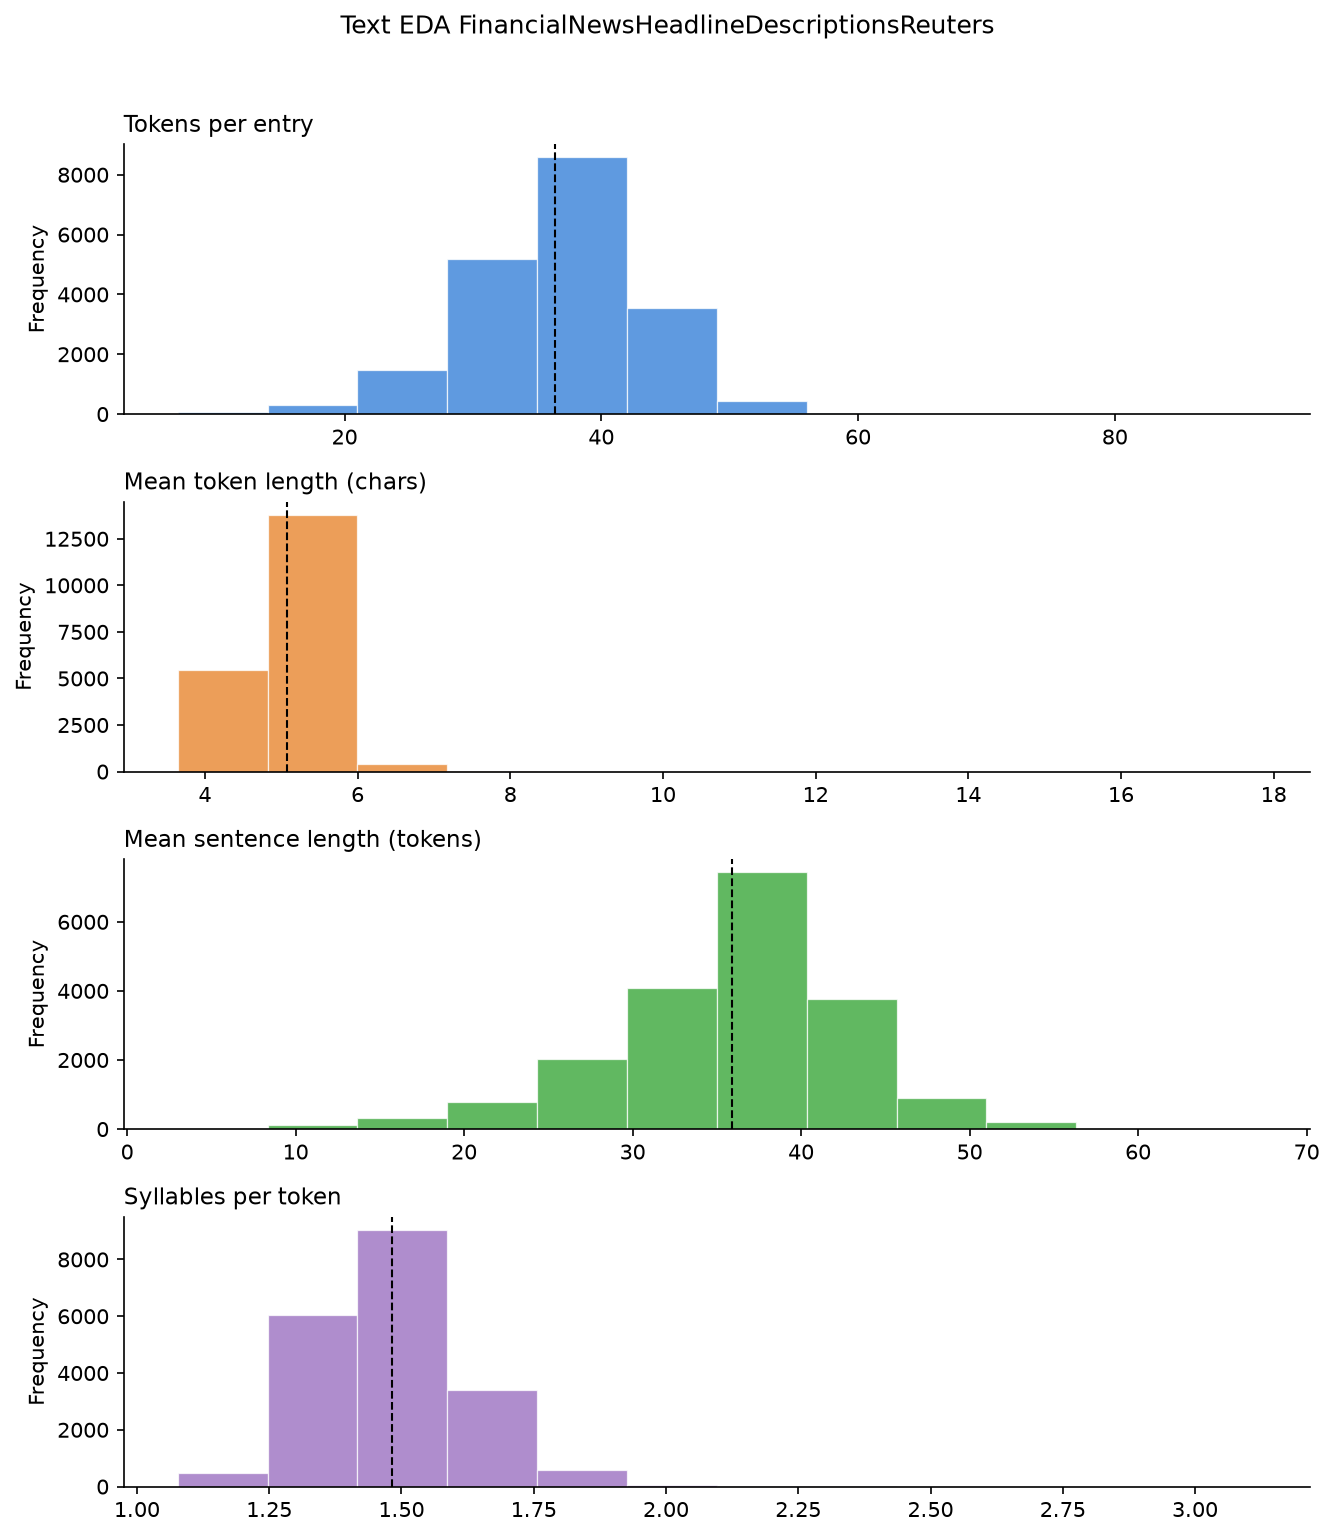

In [38]:
# text characteristics for train dataset headline descriptions

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("textdescriptives/descriptive_stats")

docs = list(nlp.pipe(df_desc["Description"]))

text_metrics = td.extract_df(
    docs,
    metrics=["descriptive_stats"]
)

METRICS = [
    "n_tokens",
    "token_length_mean",
    "sentence_length_mean",
    "syllables_per_token_mean"
]

TITLES = {
    "n_tokens": "Tokens per entry",
    "token_length_mean": "Mean token length (chars)",
    "sentence_length_mean": "Mean sentence length (tokens)",
    "syllables_per_token_mean": "Syllables per token"
}

COLORS = ["#2a78d6", "#e67e22", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(4, 1, figsize=(9, 10), dpi=150)

fig.suptitle(
    "Text EDA FinancialNewsHeadlineDescriptionsReuters",
    y=1.02
)

for ax, m, color in zip(axes, METRICS, COLORS):
    vals = text_metrics[m].dropna()

    ax.hist(
        vals,
        bins=12,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6
    )

    # Mean
    ax.axvline(
        vals.mean(),
        color="black",
        linewidth=1,
        linestyle="--"
    )

    ax.set_title(TITLES[m], fontsize=11, loc="left")
    ax.set_ylabel("Frequency")
    
    # Clean up
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [57]:
def clean(text):
    text = text.lower()
    text = re.sub('[^a-z A-Z 0-9-]+', '', text)
    text = " ".join([word for word in text.split() if word not in stopwords.words('english')])
    
    return text

df_wordfreq = df_50pct.copy()
df_wordfreq['strip_sentence'] = df_50pct['sentence'].apply(clean)
print(df_wordfreq)

                                                                                                                                                                                                                                  sentence  \
0                                                                                                          According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   
1                                           Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .   
2     The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .   
3                           With the new product

In [58]:
def corpus(text):
    text_list = text.split()
    return text_list

df_wordfreq['strip_sentence_list'] = df_wordfreq['strip_sentence'].apply(corpus)
print(df_wordfreq)

                                                                                                                                                                                                                                  sentence  \
0                                                                                                          According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   
1                                           Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .   
2     The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .   
3                           With the new product

In [66]:
corpus = []
for i in trange(df.shape[0], ncols=150, nrows=10, colour='green', smoothing=0.8):
    corpus += df_wordfreq['strip_sentence_list'][i]
    
print(f'Corpus Length: {len(corpus)}\n')

mostCommon = Counter(corpus).most_common(10)
print(mostCommon)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 3453/3453 [00:00<00:00, 68150.80it/s]

Corpus Length: 46106

[('company', 615), ('eur', 605), ('said', 399), ('finnish', 375), ('sales', 299), ('million', 287), ('net', 277), ('mn', 272), ('finland', 244), ('group', 233)]


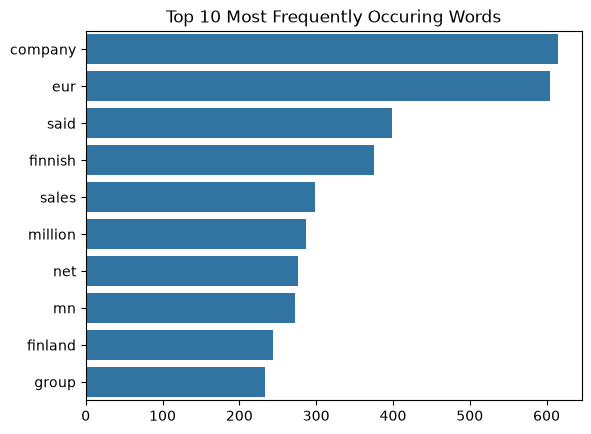

In [67]:
words = []
freq = []
for word, count in mostCommon:
    words.append(word)
    freq.append(count)

sns.barplot(x=freq, y=words)
plt.title('Top 10 Most Frequently Occuring Words')
plt.show()

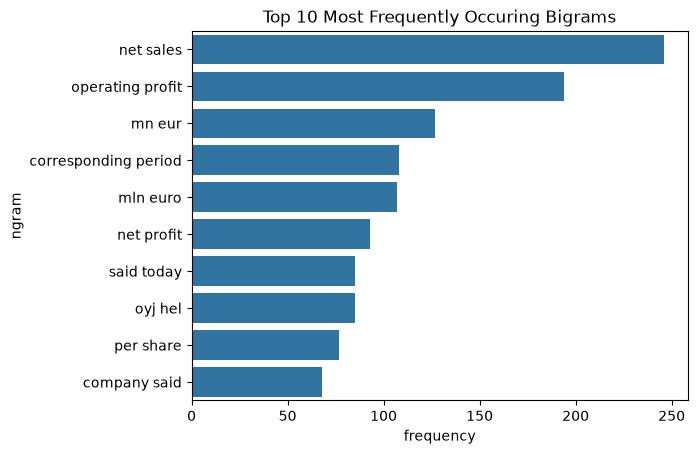

In [73]:
cv = CountVectorizer(ngram_range=(2,2))
bigrams = cv.fit_transform(df_wordfreq['strip_sentence'])

count_values = bigrams.toarray().sum(axis=0)
ngram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv.vocabulary_.items()], reverse = True))
ngram_freq.columns = ["frequency", "ngram"]

sns.barplot(x=ngram_freq['frequency'][:10], y=ngram_freq['ngram'][:10])
plt.title('Top 10 Most Frequently Occuring Bigrams')
plt.show()

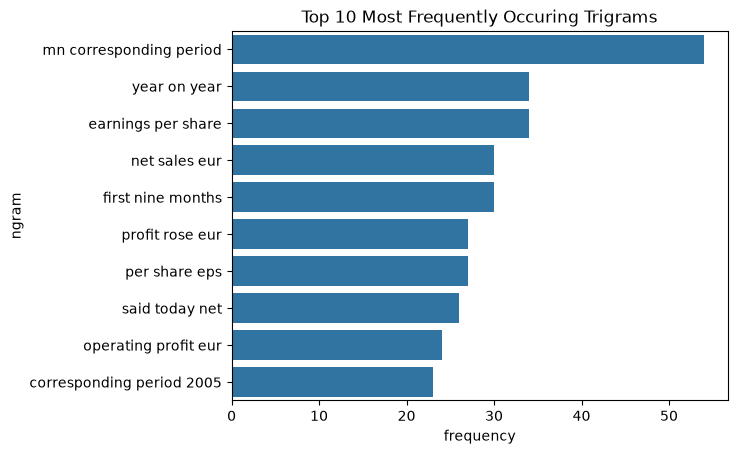

In [74]:
cv1 = CountVectorizer(ngram_range=(3,3))
trigrams = cv1.fit_transform(df_wordfreq['strip_sentence'])
count_values = trigrams.toarray().sum(axis=0)
ngram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv1.vocabulary_.items()], reverse = True))
ngram_freq.columns = ["frequency", "ngram"]

sns.barplot(x=ngram_freq['frequency'][:10], y=ngram_freq['ngram'][:10])
plt.title('Top 10 Most Frequently Occuring Trigrams')
plt.show()

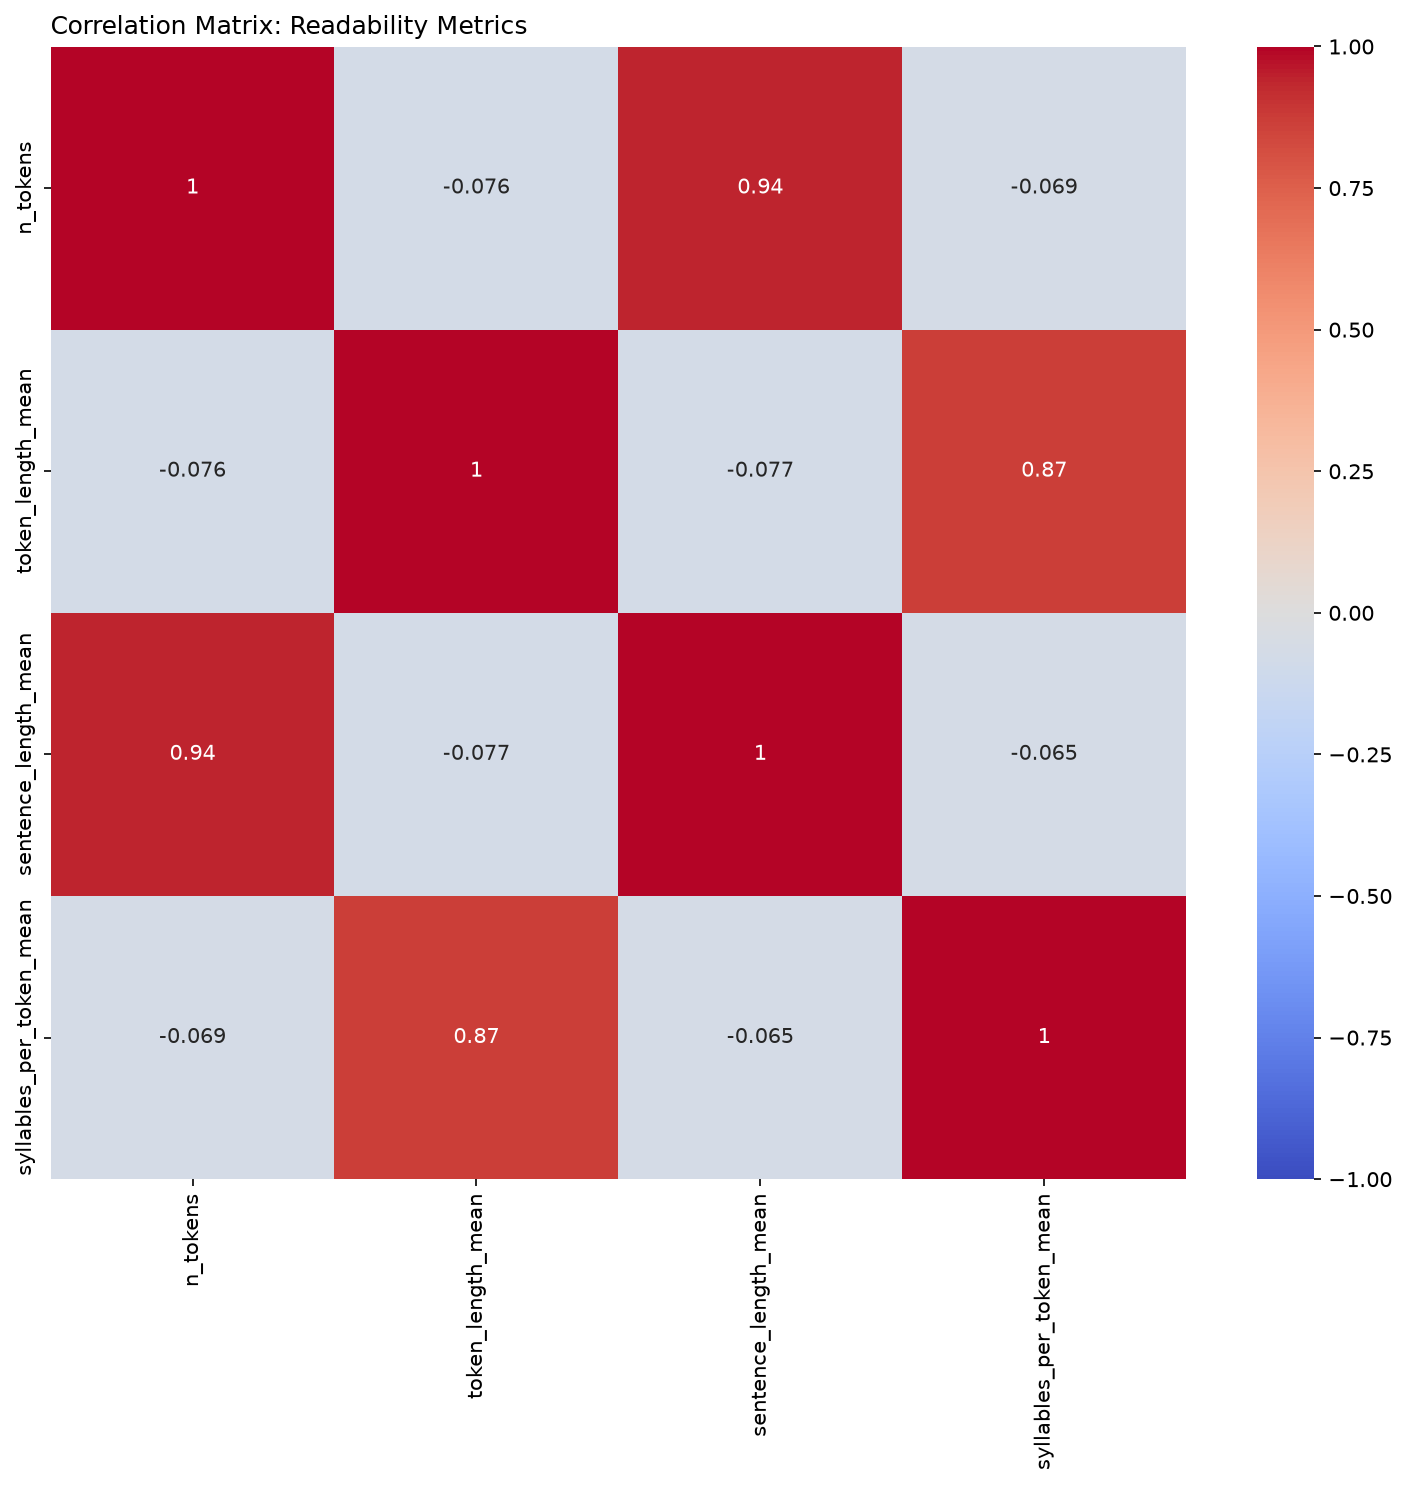

In [95]:
# correlation matrix across your
df_univar = text_metrics.copy()
df_univar["label"] = df_50pct["label"].values
METRICS = ["n_tokens", "token_length_mean", "sentence_length_mean", "syllables_per_token_mean"]
corr = df_univar[METRICS].corr()

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix: Readability Metrics", loc="left")
plt.tight_layout()
plt.show()

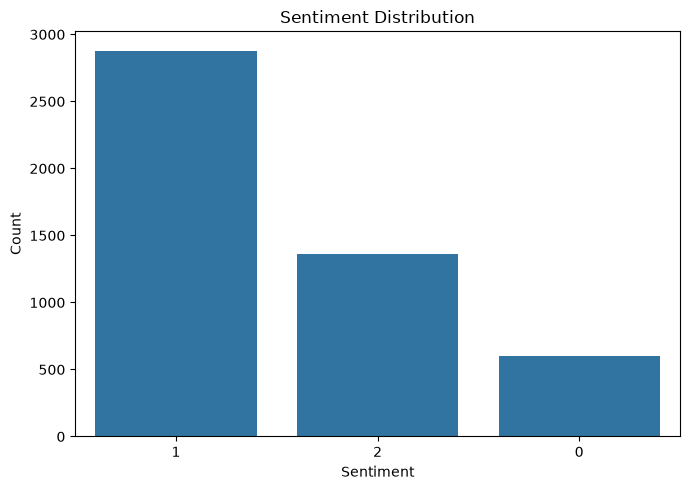

label
1    2879
2    1363
0     604
Name: count, dtype: int64


In [76]:
# plot sentiment distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_50pct,
    x="label",
    order=df_50pct["label"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df_50pct['label'].value_counts())

In [96]:
# build df_multivar from the computed metrics + label from df_50pct
df_multivar = text_metrics.copy()
df_multivar["label"] = df_50pct["label"].values

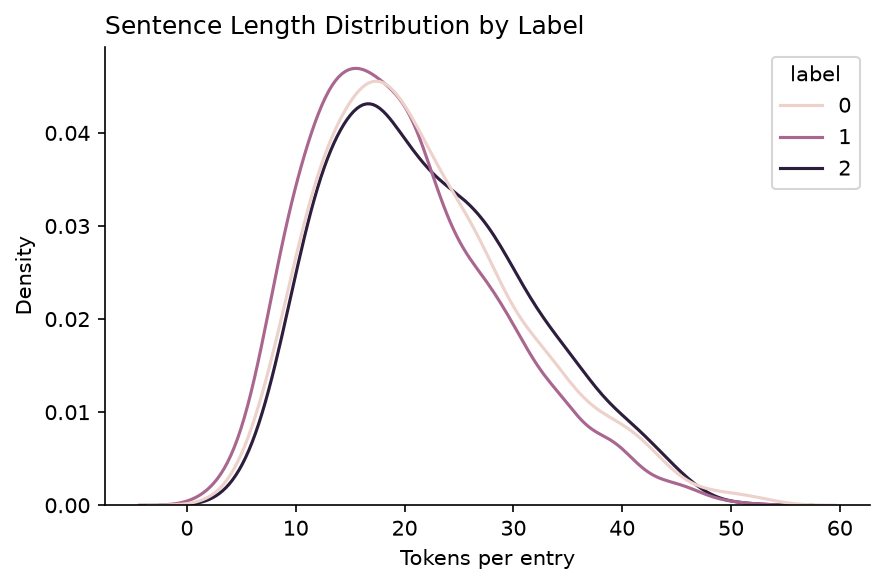

In [85]:
# overlaid density by label
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
sns.kdeplot(data=df_multivar, x="n_tokens", hue="label", common_norm=False, ax=ax)
ax.set_title("Sentence Length Distribution by Label", loc="left")
ax.set_xlabel("Tokens per entry")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

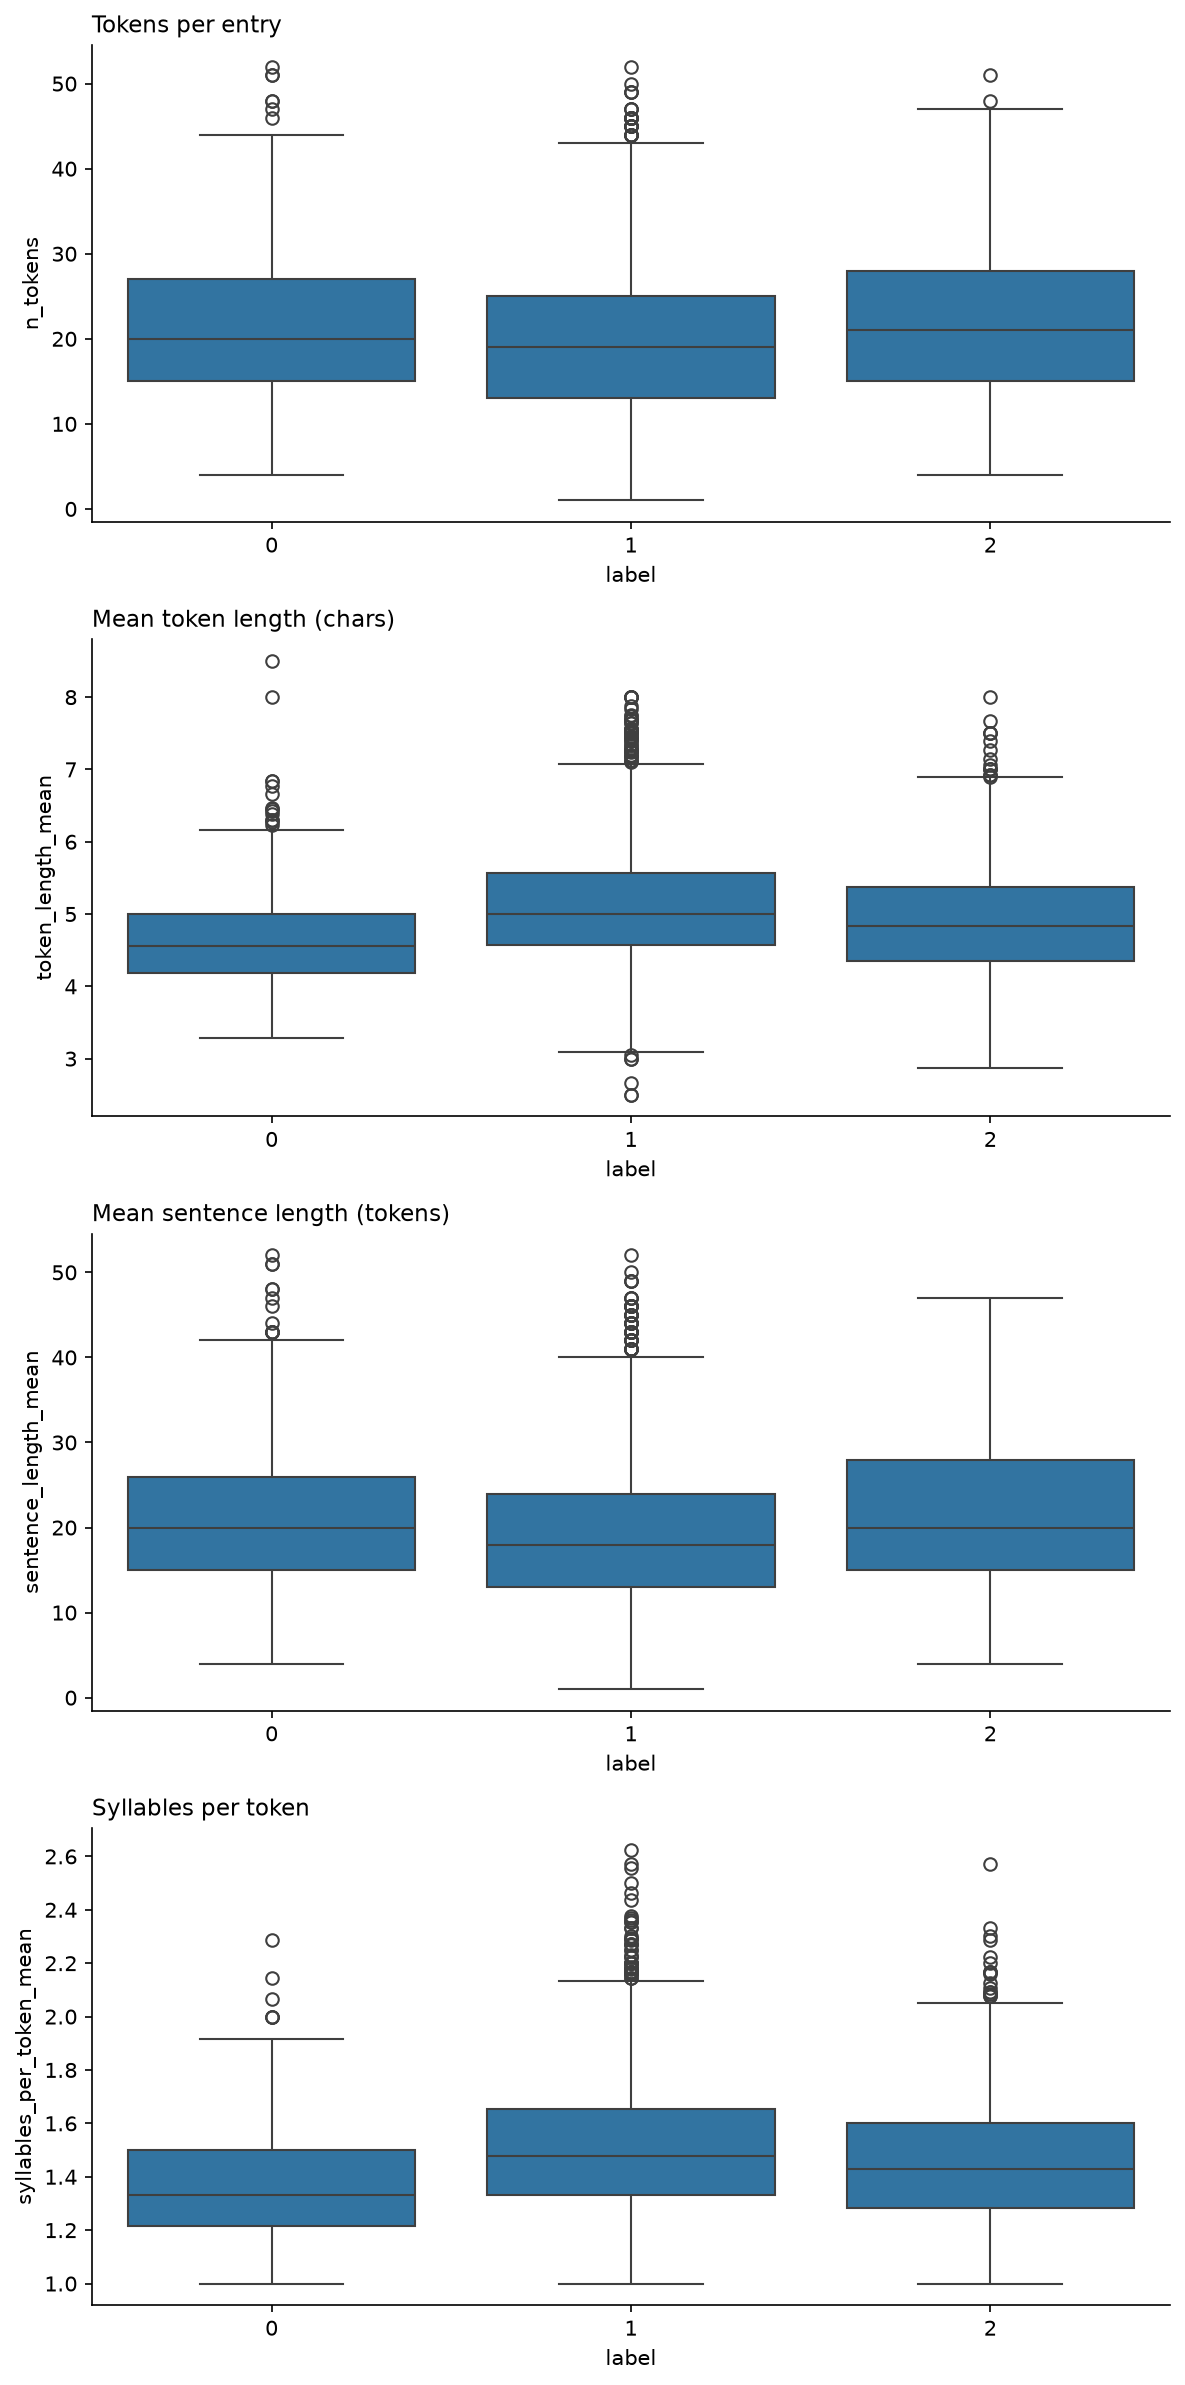

In [92]:
# text information vs labels
fig, axes = plt.subplots(4, 1, figsize=(8, 16), dpi=150)
for ax, m in zip(axes, METRICS):
    sns.boxplot(data=df_multivar, x="label", y=m, ax=ax)
    ax.set_title(TITLES[m], fontsize=11, loc="left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()